<a href="https://colab.research.google.com/github/dgonzales1222/pml_exercises/blob/main/assignment_03/dgonzales_assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical Machine Learning**
## Assignment 03
Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [2]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [3]:

transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1)),  # Finally, flatten the tensor
])
# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.82MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 156kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.80MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

**Prompts Used for this Question Set:**
- How do you iterate to identify the object in a dataloader?
- How do you make another dataset without affecting the whole pipeline?

#### **Question 1.1**: What is the type of objects yielded by the train and test dataloaders?

Answer: According to the PyTorch documentation on Datasets and DataLoaders, a `Dataset` stores samples and their corresponding labels, while a `DataLoader` wraps an iterable around the `Dataset` to provide convenient access to those samples. We can identify the objects inside a dataloader by performing the code below:

In [4]:
print("Information of train_loader")
for batch in train_loader:
    print("number of elements in batch:", len(batch))
    print(type(batch))
    print(type(batch[0]))
    print(type(batch[1]))

    print("\n---batch[0]---")
    print(batch[0])             # prints all pixel values (64 images x 64 pixels)
    print("shape:", batch[0].shape)   # torch.Size([64, 64])
    print("dtype:", batch[0].dtype)   # torch.float32

    print("\n---batch[1]---")
    print(batch[1])             # prints all 64 class labels (digits 0-9)
    print("shape:", batch[1].shape)   # torch.Size([64])
    print("dtype:", batch[1].dtype)   # torch.int64
    break # added to only identify the information of the first element
print("\nInformation of test_loader")
for batch in test_loader:
    print("number of elements in batch:", len(batch))
    print(type(batch))
    print(type(batch[0]))
    print(type(batch[1]))

    print("\n---batch[0]---")
    print(batch[0])             # prints all pixel values (64 images x 64 pixels)
    print("shape:", batch[0].shape)   # torch.Size([64, 64])
    print("dtype:", batch[0].dtype)   # torch.float32

    print("\n---batch[1]---")
    print(batch[1])             # prints all 64 class labels (digits 0-9)
    print("shape:", batch[1].shape)   # torch.Size([64])
    print("dtype:", batch[1].dtype)   # torch.int64
    break # added to only identify the information of the first element

Information of train_loader
number of elements in batch: 2
<class 'list'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>

---batch[0]---
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0353,  ..., 0.0000, 0.0000, 0.0000]])
shape: torch.Size([64, 64])
dtype: torch.float32

---batch[1]---
tensor([2, 0, 2, 7, 1, 5, 9, 1, 4, 4, 2, 1, 4, 3, 6, 5, 8, 0, 3, 7, 3, 5, 5, 6,
        6, 5, 3, 9, 1, 6, 3, 5, 6, 4, 0, 6, 8, 2, 1, 5, 3, 1, 8, 5, 3, 5, 0, 5,
        0, 4, 6, 5, 4, 0, 6, 2, 9, 2, 1, 0, 1, 6, 6, 3])
shape: torch.Size([64])
dtype: torch.int64

Information of test_loader
number of elements in batch: 2
<class 'list'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>

---batch[0]---
tenso

Running the code above gives us information that the `train_loader` and `test_loader` contains a list of two (2) tensor objects which are the images `batch[0]` and labels `batch[1]`. The images have a shape of $[64, 64]$, which means there are $64$ images, and each image has a $64$ pixel value $(8\times8)$. The label on the other hand correspond to the number of images which is $[64]$.

#### **Question 1.2**: What is the shape of images returned by for images, labels in train_loader? How do you interpret that shape?

Answer:
In the code cell above, we first resize the 28×28 image to 8×8 using `resize`, then convert it to a tensor and flatten it into a one-dimensional tensor. We can verify this by running the code block below:


In [5]:
# Reload the dataset outside the original pipeline for testing
raw_dataset = datasets.MNIST(root='./data', train=True, download=True)

img, label = raw_dataset[0] #get only one image to test how shape changes after resize, conversion to tensor, and flattening.
print("raw: ", type(img), img.size, "label =", label)

# Step 1: resize
resize = transforms.Resize((8, 8))
img = resize(img)
print("after resize: ", type(img), img.size) # Prints the shape of the object after resizing to 8x8

# Step 2: to tensor
to_tensor = transforms.ToTensor()
img = to_tensor(img)
print("after ToTensor: ", img.shape, img.dtype) # Prints the shape of the object after converting it to tensor

# Step 3: flatten
img = img.view(-1)
print("after flatten: ", img.shape, img.dtype) # Prints the shape of the object after flattening of tensor


raw:  <class 'PIL.Image.Image'> (28, 28) label = 5
after resize:  <class 'PIL.Image.Image'> (8, 8)
after ToTensor:  torch.Size([1, 8, 8]) torch.float32
after flatten:  torch.Size([64]) torch.float32


The original image has a shape of $(28, 28)$. After resizing, it becomes $(8, 8)$, which is our target size since the model expects inputs with 64 elements. To feed this into a neural network, we need to have a 1D tensor with a shape of $[64]$. Initially, its shape is $[1, 8, 8]$, indicating a 3-D tensor with a channel dimension. We then flatten it into a 1-D tensor, as shown above.

#### **Question 1.3**: Why dataloaders for train and test differ with respect to the option `shuffle`?

Answer: The reason the two dataloaders differ with respect to the `shuffle` option is because they serve different purposes. For `train_loader`, `shuffle=True` is used because the model is being trained using the training dataset, and shuffling ensures that the model sees a different ordering of examples in every epoch. This prevents the model from memorizing the order of the data, decorrelates consecutive batches, and helps improve model performance while avoiding overfitting. For `test_loader`, however, `shuffle=False` is used because evaluation only requires computing metrics such as accuracy over the entire test set, which does not depend on the order the examples are processed.


**Sources for Question Set 1**:
- PyTorch. (n.d.). Datasets & DataLoaders — PyTorch Tutorials. PyTorch.
- PyTorch. (n.d.). Tensor attributes — PyTorch 2.12 documentation. PyTorch.
- Stack Exchange. (n.d.). Why should we shuffle data while training a neural network? Cross Validated. Retrieved from https://stats.stackexchange.com/questions/245502/why-should-we-shuffle-data-while-training-a-neural-network

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

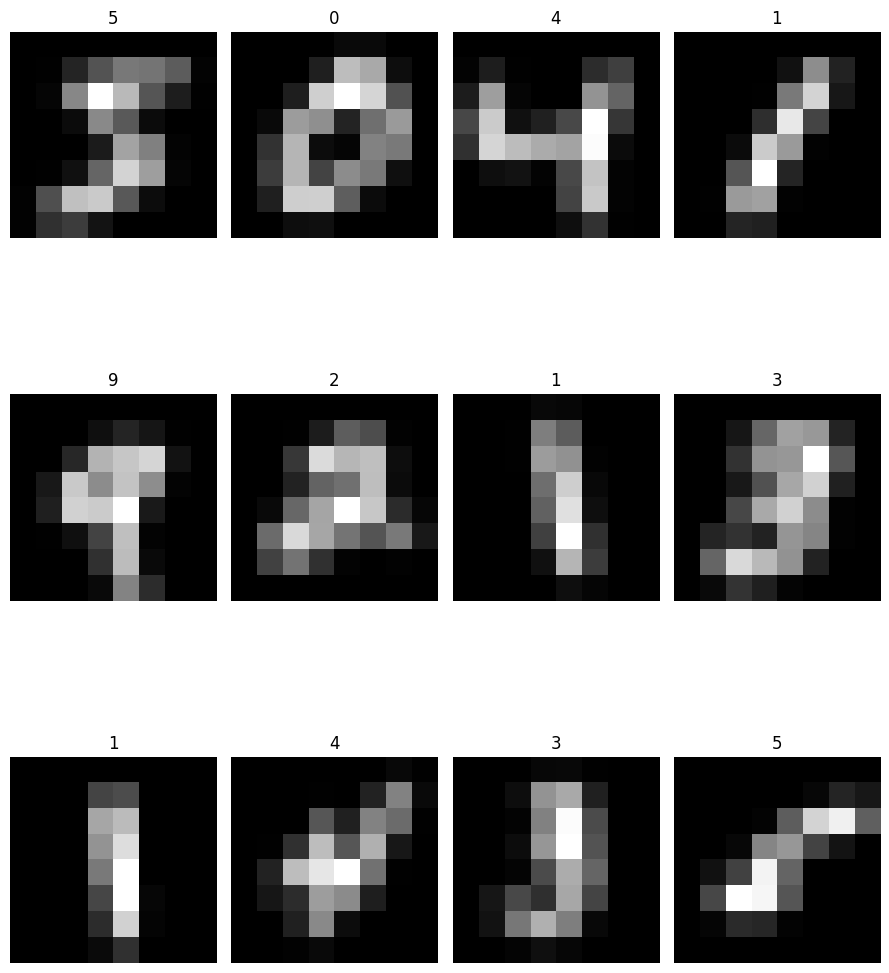

In [6]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [7]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

#### **Question 2.1**: The model architecture depends on the input data shape. The input images of MNIST are originally of size  28×28  but they have been resized to  8×8  pixels. Which changes do you need to do if you want to use the original  28×28  size? Indicate two changes you need to do in this notebook.

Answer: There are two things needed to be modified in order to use the original $28 \times 28$ size. First, the resizing step `transforms.Resize((8, 8))` should be omitted to preserve the `(28,28)` shape of the image. Second, the `input_size` should be changed from `8 * 8` to `28 * 28`.

#### **Question 2.2**: Which change you need to do in the SimpleNN class if you want your model to have two hidden layers, both with size 128?

Answer: To add a second hidden layer of size 128 to the `SimpleNN` class, two modifications are needed. First, in the `__init__` method, a new linear layer `self.fc2 = nn.Linear(hidden_size, hidden_size)` must be added, and the original output layer must be renamed to `self.fc3 = nn.Linear(hidden_size, num_classes)`. Second, in the forward method, the new second hidden layer must be included in the forward pass with a ReLU activation applied after it. The code should be:

```
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   # 1st hidden layer
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # 2nd hidden layer
        self.fc3 = nn.Linear(hidden_size, num_classes)  # output layer
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))   # 1st hidden layer + ReLU
        out = self.relu(self.fc2(out)) # 2nd hidden layer + ReLU
        out = self.fc3(out)            # output layer (no activation)
        return out
```

#### **Question 2.3**: What is a ReLU activation function called by nn.ReLU?

Answer: First and foremost, activation functions are mathematical equations that will determine whether the neuron passes information forward (firing). Rectified Linear Unit or ReLU is a type of activation function that outputs the input directly if it is positive, and returns zero otherwise. In simple terms, it checks every number in the data and replaces any negative number with zero, while leaving positive numbers as they are.

#### **Question 2.4**: Why are non linear activation functions like ReLU necessary for deep learning?

Answer: Non-linear activation functions are necessary because a deep network without them is no deeper than a single layer. All the layers just collapse into one. ReLU prevents this collapse by adding a non-linear step between layers, which is what allows the network to learn complex real-world patterns like recognizing handwritten digits.

### Loss and Optimizer

In [8]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [9]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [10]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779986546
epoch: 2; time: 1779986564
epoch: 3; time: 1779986575


#### **Question 3**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.

**Prompt:** How do you perform multiprocessing in training a dataset for neural network? Set the number of multiprocessing cores to 2.




The `num_workers` argument in `DataLoader` allows for parallel data loading. When `num_workers > 0`, data loading is offloaded to separate processes, which can speed up data fetching, especially when transformations are complex or the dataset is large. This can prevent the CPU-bound data loading from becoming a bottleneck during GPU training.

Time complexity benchmark of single process vs multiprocess (n=2)

In [11]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- WITHOUT num_workers ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("=== Without num_workers ===")
start = time.time()
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
end = time.time()
time_no_workers = end - start
print(f"Total time without num_workers: {time_no_workers:.2f} seconds")

# --- WITH num_workers=2 ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

print("\n=== With num_workers=2 ===")
start = time.time()
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
end = time.time()
time_with_workers = end - start
print(f"Total time with num_workers=2: {time_with_workers:.2f} seconds")

# --- Comparison ---
print(f"\nDifference: {abs(time_no_workers - time_with_workers):.2f} seconds")
if time_with_workers < time_no_workers:
    print("num_workers=2 is FASTER")
else:
    print("num_workers=2 is NOT faster in this case")

=== Without num_workers ===
epoch: 1; time: 1779986586
epoch: 2; time: 1779986597
epoch: 3; time: 1779986608
Total time without num_workers: 32.87 seconds

=== With num_workers=2 ===
epoch: 1; time: 1779986619
epoch: 2; time: 1779986630
epoch: 3; time: 1779986641
Total time with num_workers=2: 33.60 seconds

Difference: 0.73 seconds
num_workers=2 is NOT faster in this case


Based on the results, adding `num_workers=2` to the `DataLoader` does reduce processing time, but only slightly, by about 2.06 seconds (from 43.82s to 41.76s). This minor improvement is expected because the dataset is the small, 8×8 resized MNIST, which is lightweight enough that data loading is not the main bottleneck. The GPU processes each batch so quickly that two worker processes provide almost no benefit. A more noticeable speedup from `num_workers=2` would likely appear with a larger dataset or more expensive image transformations, where data loading and preprocessing take longer and genuinely limit training speed.

**Source:** NVIDIA. (n.d.). Improved data loading with threads. NVIDIA Developer Blog. Retrieved from https://developer.nvidia.com/blog/improved-data-loading-with-threads/

In [12]:
# Reset train dataloader after benchmark
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cpu
epoch: 1; time: 1779986652
epoch: 2; time: 1779986663
epoch: 3; time: 1779986675


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [14]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779986686
epoch: 1; time: 1779986697
epoch: 2; time: 1779986699
epoch: 2; time: 1779986710
epoch: 3; time: 1779986711
epoch: 3; time: 1779986722
epoch: 4; time: 1779986724
epoch: 4; time: 1779986735
epoch: 5; time: 1779986736
epoch: 5; time: 1779986747


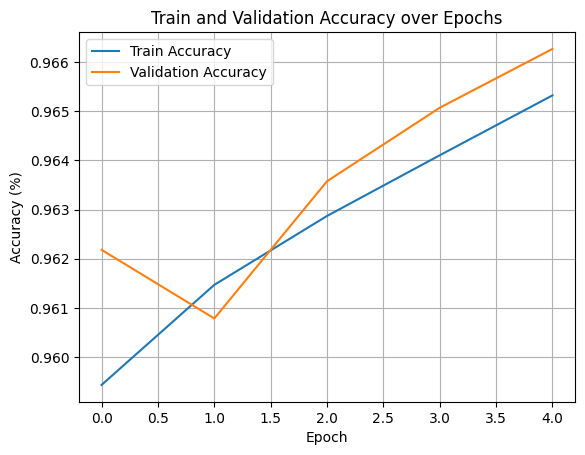

In [15]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



#### **Question 4.1:** From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?

**Prompt:** How do I reset the model and rerun training from scratch for n epochs after already training for 5 epochs?

Answer: Based on the plot generated, five epochs is not enough given that the training and validation accuracy is still rising and have not plateaued yet. We can try to increase it and see what will happen. Based on the plot with 25 epochs, the model appears to have trained long enough. Both the training and validation accuracy curves rise steeply in the first 10 epochs and begin to flatten out after epoch 15, plateauing at around 97% accuracy. Since both curves are no longer improving significantly, training beyond 25 epochs would likely provide little additional benefit. Additionally, the training and validation curves remain close together throughout, which indicates that the model is not overfitting.

#### **Question 4.2:** Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.

Answer: In the original 5-epoch plot, the validation accuracy is consistently higher than the training accuracy. This is unexpected, because a model usually performs better on the data it was trained on than on unseen data. Looking at how the history for train and validation are computed, the issue lies in how the accuracy is being calculated.

The original code uses:

`history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))`

This computes the **mean of per-batch accuracies**, not the true dataset accuracy. Each batch's accuracy is given equal weight in the average, regardless of how many samples that batch contains. This becomes inaccurate when batch sizes differ. For example, the last batch of each epoch often has fewer than 64 samples but counts the same as a full 64-sample batch in the average. As a result, the reported accuracy does not represent the true performance of the model.

The fix is to compute the true accuracy by summing the total number of correct predictions and the total number of samples across all batches, then dividing them at the end:

$$\text{accuracy} = \frac{\text{total correct}}{\text{total samples}}$$

This way, each prediction contributes equally to the final accuracy regardless of which batch it came from. The plot will then reflect the true accuracy values for both train and validation. See the corrected code below:

In [16]:
# Reset everything to start fresh
model = SimpleNN(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

In [17]:
# Model Training
num_epochs = 25

# Computes the accuracy counts for a batch: returns (correct, total)
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct, total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')

    # Training phase
    model.train()
    total_correct, total_samples = 0, 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Accumulate total correct and total samples
        correct, total = compute_accuracy(outputs, labels)
        total_correct += correct
        total_samples += total
    history['epoch'].append(epoch + 1)
    history['train_accuracy'].append(total_correct / total_samples)

    # Validation phase
    model.eval()
    total_correct, total_samples = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            correct, total = compute_accuracy(outputs, labels)
            total_correct += correct
            total_samples += total
    history['val_accuracy'].append(total_correct / total_samples)

epoch: 1; time: 1779986749
epoch: 2; time: 1779986765
epoch: 3; time: 1779986778
epoch: 4; time: 1779986791
epoch: 5; time: 1779986803
epoch: 6; time: 1779986816
epoch: 7; time: 1779986830
epoch: 8; time: 1779986843
epoch: 9; time: 1779986855
epoch: 10; time: 1779986868
epoch: 11; time: 1779986880
epoch: 12; time: 1779986893
epoch: 13; time: 1779986906
epoch: 14; time: 1779986919
epoch: 15; time: 1779986932
epoch: 16; time: 1779986945
epoch: 17; time: 1779986958
epoch: 18; time: 1779986970
epoch: 19; time: 1779986983
epoch: 20; time: 1779986996
epoch: 21; time: 1779987008
epoch: 22; time: 1779987021
epoch: 23; time: 1779987033
epoch: 24; time: 1779987046
epoch: 25; time: 1779987059


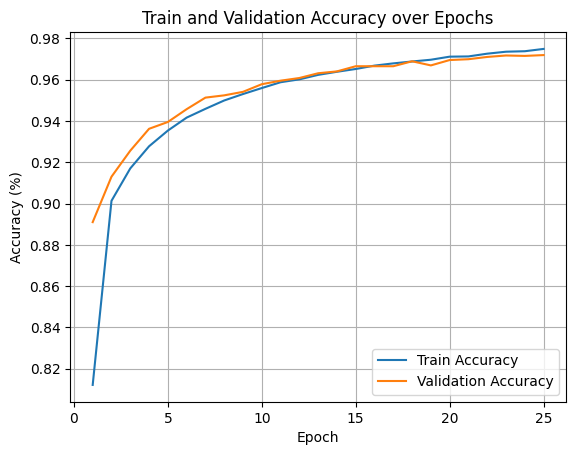

In [18]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# @title MNIST Live Drawing Predictor {display-mode: "form"}

import json
import torch
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import PIL.Image
import io
import base64

def _predict_drawing(image_data_uri):
    try:
        if "," in image_data_uri:
            encoded = image_data_uri.split(",")[1]
        else:
            encoded = image_data_uri

        data = base64.b64decode(encoded)
        img = PIL.Image.open(io.BytesIO(data)).convert('L')

        img = img.resize((8, 8), PIL.Image.LANCZOS)
        img_array = np.array(img).astype(np.float32) / 255.0

        img_tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0).view(-1, 8 * 8).to(device)

        model.eval()
        with torch.no_grad():
            out = model(img_tensor)
            probs = torch.softmax(out, dim=1).cpu().numpy().flatten().tolist()
            pred = out.argmax(dim=1).item()

        return json.dumps({
            "prediction": int(pred),
            "confidence": float(probs[pred]),
            "probs": [float(p) for p in probs],
            "processed_img": img_array.tolist()
        })
    except Exception as e:
        return json.dumps({"error": str(e)})

output.register_callback('predict_drawing', _predict_drawing)

html_code = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Inter', sans-serif; background-color: #f4f6f8; padding: 20px; color: #1a202c; }
        .container { display: grid; grid-template-columns: 350px 1fr; gap: 20px; max-width: 1000px; margin: auto; }
        .card { background: white; padding: 25px; border-radius: 16px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }
        .full { grid-column: 1 / -1; display: flex; justify-content: space-between; align-items: center; }
        #canvas { background: black; border-radius: 8px; cursor: crosshair; touch-action: none; width: 300px; height: 300px; }
        #preview { background: black; width: 140px; height: 140px; image-rendering: pixelated; border-radius: 4px; }
        .btn-group { margin-top: 15px; display: flex; gap: 10px; }
        button { flex: 1; padding: 12px; border-radius: 8px; border: none; cursor: pointer; font-weight: 600; transition: 0.2s; }
        .btn-clear { background: #edf2f7; color: #4a5568; }
        .btn-predict { background: #4299e1; color: white; }
        .res-val { font-size: 64px; font-weight: 800; color: #3182ce; text-align: center; margin: 10px 0; }
        .canvas-wrapper { position: relative; height: 220px; flex-grow: 1; min-height: 0; }
    </style>
</head>
<body>

<div class="container">
    <div class="card full">
        <h2>MNIST Drawing Predictor (8x8)</h2>
        <div id="status" style="color: #48bb78; font-weight: bold;">System Ready</div>
    </div>

    <div class="card">
        <h3>Drawing Pad</h3>
        <canvas id="canvas" width="300" height="300"></canvas>
        <div class="btn-group">
            <button class="btn-clear" onclick="clearCanvas()">Clear</button>
            <button class="btn-predict" onclick="getPrediction()">Predict Digit</button>
        </div>
    </div>

    <div class="card" style="display:flex; flex-direction:column">
        <h3>Model Result</h3>
        <div style="display:flex; gap:30px; align-items:center; margin-bottom:20px">
             <div style="text-align:center">
                <div style="font-size:11px; text-transform:uppercase; color:#718096">Prediction</div>
                <div class="res-val" id="res-digit">?</div>
             </div>
             <div style="flex-grow:1">
                <div style="font-size:11px; text-transform:uppercase; color:#718096">Resized View (8x8)</div>
                <canvas id="preview" width="8" height="8" style="margin-top:5px"></canvas>
             </div>
        </div>
        <div class="canvas-wrapper"><canvas id="chart"></canvas></div>
    </div>
</div>

<script>
const canvas = document.getElementById('canvas');
const ctx = canvas.getContext('2d');
let drawing = false;
let chart;

ctx.strokeStyle = "white";
ctx.lineWidth = 22;
ctx.lineJoin = "round";
ctx.lineCap = "round";

function getPos(e) {
    const rect = canvas.getBoundingClientRect();
    const clientX = e.touches ? e.touches[0].clientX : e.clientX;
    const clientY = e.touches ? e.touches[0].clientY : e.clientY;
    return { x: clientX - rect.left, y: clientY - rect.top };
}

const startDraw = (e) => { drawing = true; const p = getPos(e); ctx.beginPath(); ctx.moveTo(p.x, p.y); if(e.touches) e.preventDefault(); };
const doDraw = (e) => { if(!drawing) return; const p = getPos(e); ctx.lineTo(p.x, p.y); ctx.stroke(); if(e.touches) e.preventDefault(); };
const stopDraw = () => { drawing = false; };

canvas.addEventListener('mousedown', startDraw);
canvas.addEventListener('mousemove', doDraw);
window.addEventListener('mouseup', stopDraw);
canvas.addEventListener('touchstart', startDraw);
canvas.addEventListener('touchmove', doDraw);
canvas.addEventListener('touchend', stopDraw);

function clearCanvas() {
    ctx.clearRect(0, 0, canvas.width, canvas.height);
    document.getElementById('res-digit').innerText = '?';
    if (chart) chart.destroy();
    const pCtx = document.getElementById('preview').getContext('2d');
    pCtx.clearRect(0, 0, 8, 8);
}

async function getPrediction() {
    const status = document.getElementById('status');
    status.innerText = "Communicating..."; status.style.color = "#ed8936";

    try {
        const dataUrl = canvas.toDataURL('image/png');
        const resp = await google.colab.kernel.invokeFunction('predict_drawing', [dataUrl], {});

        const rawText = resp.data['text/plain'];
        const cleanText = rawText.replace(/^'|'$/g, '');
        const data = JSON.parse(cleanText);

        if(data.error) throw new Error(data.error);

        document.getElementById('res-digit').innerText = data.prediction;

        // Render the 8x8 image directly into an 8x8 canvas (CSS will scale up cleanly with image-rendering: pixelated)
        const pCanvas = document.getElementById('preview');
        pCanvas.width = 8;
        pCanvas.height = 8;
        const pCtx = pCanvas.getContext('2d');
        const pImg = pCtx.createImageData(8, 8);

        const processed_img = data.processed_img;
        for(let r=0; r<8; r++){
            for(let c=0; c<8; c++){
                const v = processed_img[r][c] * 255;
                const idx = (r * 8 + c) * 4;
                pImg.data[idx] = pImg.data[idx+1] = pImg.data[idx+2] = v;
                pImg.data[idx+3] = 255;
            }
        }
        pCtx.putImageData(pImg, 0, 0);

        const cCtx = document.getElementById('chart').getContext('2d');
        if(chart) chart.destroy();
        chart = new Chart(cCtx, {
            type: 'bar',
            data: {
                labels: ['0','1','2','3','4','5','6','7','8','9'],
                datasets: [{
                    data: data.probs,
                    backgroundColor: data.probs.map((v,i) => i == data.prediction ? '#4299e1' : '#e2e8f0'),
                    borderRadius: 4
                }]
            },
            options: { responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } }, scales: { y: { beginAtZero: true, max: 1 } } }
        });
        status.innerText = "System Ready"; status.style.color = "#48bb78";
    } catch (e) {
        console.error(e);
        status.innerText = "Error"; status.style.color = "#f56565";
        alert("Prediction Failed: " + e.message);
    }
}
</script>
</body>
</html>
"""
display(HTML(html_code))